In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters
import shutil
import krippendorff

In [12]:
plt.style.use("default")

In [3]:
pd.set_option("display.max_rows", None)

In [ ]:
path1 = "ZPD_annotated_by_everyone_JW/train"
path2 = "ZPD_annotated_by_everyone_SL/train"
path3 = "ZPD_annotated_by_everyone_KS/train"

In [5]:
def get_image_annotations(base_folder_path):
    annotation_dict = {}
    
    for class_name in os.listdir(base_folder_path):
        class_dir = os.path.join(base_folder_path, class_name)
        
        if os.path.isdir(class_dir):
            for image_name in os.listdir(class_dir):
                image_path = os.path.join(class_dir, image_name)

                base_img_name = image_name.split("_jpg")[0]
                
                if os.path.isfile(image_path):
                    annotation_dict[base_img_name] = class_name
                    
    return annotation_dict

def compare_annotations(folder1, folder2, folder3):
	dict1 = get_image_annotations(folder1)
	dict2 = get_image_annotations(folder2)
	dict3 = get_image_annotations(folder3)

	all_image_names = set(dict1.keys()) | set(dict2.keys()) | set(dict3.keys())

	data = []
	for img in all_image_names:
		label1 = dict1.get(img, None)
		label2 = dict2.get(img, None)
		label3 = dict3.get(img, None)
		
		is_match = (label1 == label2 == label3) and (label1 is not None)
		
		annotator1 = folder1.split("/train")[0][-2:]
		annotator2 = folder2.split("/train")[0][-2:]
		annotator3 = folder3.split("/train")[0][-2:]

		data.append({
			"Image Name": img,
			annotator1: label1,
			annotator2: label2,
			annotator3: label3,
			"Match": is_match
		})

		df = pd.DataFrame(data)

		df = df.sort_values(by="Image Name").reset_index(drop=True)

	return df

In [6]:
results_df = compare_annotations(path1, path2, path3)

In [7]:
results_df

,Image Name,JW,SL,KS,Match
0,image_100,none,none,none,True
1,image_101,u,u,u,True
2,image_104,a,a,a,True
3,image_106,a,a,a,True
4,image_109,u,u,u,True
5,image_11,e,e,e,True
6,image_111,none,none,none,True
7,image_112,none,none,none,True
8,image_115,u,u,u,True
9,image_126,y,y,y,True


In [8]:
print((results_df["JW"] == results_df["SL"]).mean())
print((results_df["JW"] == results_df["KS"]).mean())
print((results_df["SL"] == results_df["KS"]).mean())

0.9576719576719577
0.9629629629629629
0.9735449735449735


In [9]:
unique_classes = set(results_df["JW"]) | set(results_df["JW"]) | set(results_df["JW"])

In [10]:
disagreements = results_df[results_df["Match"] == False]

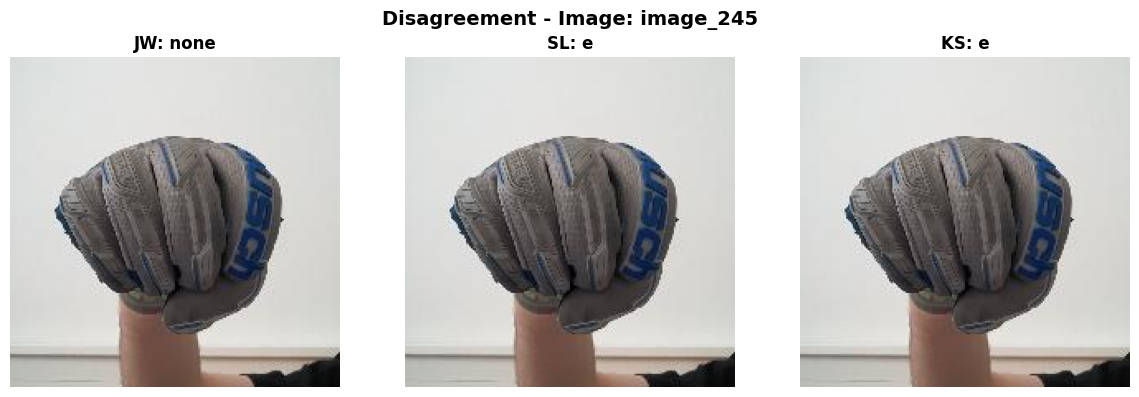

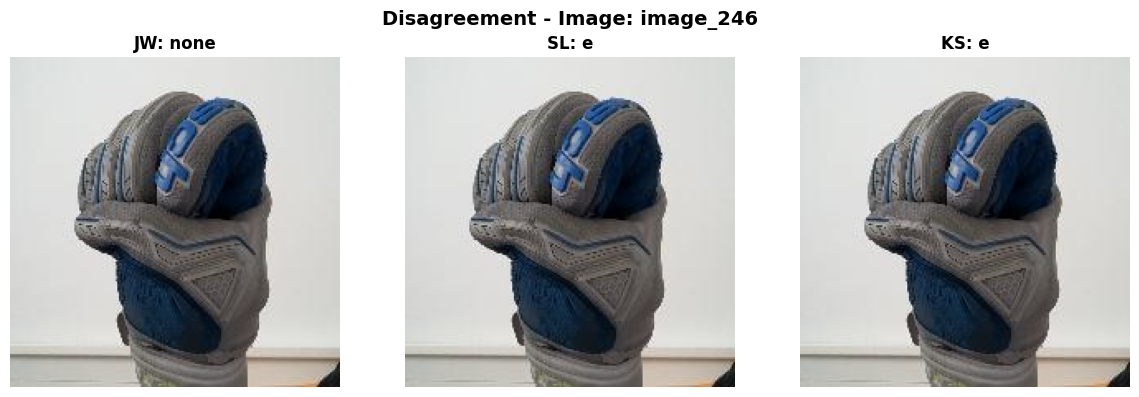

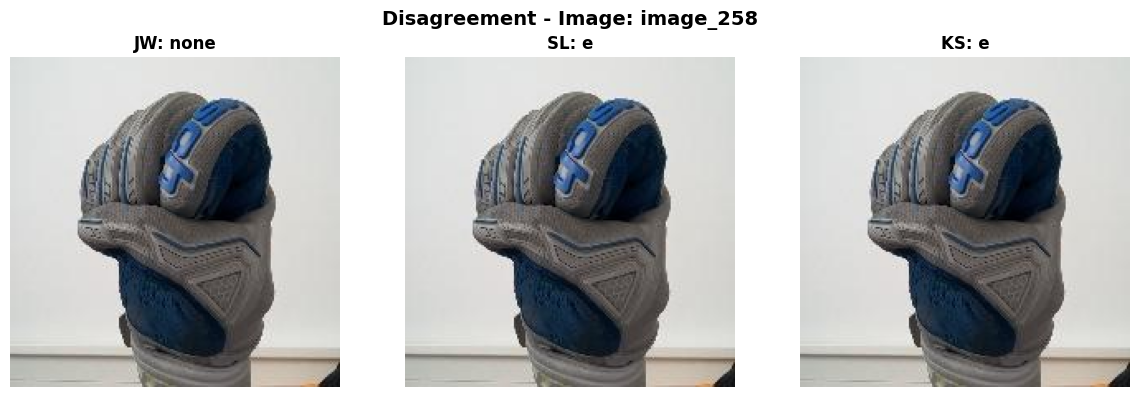

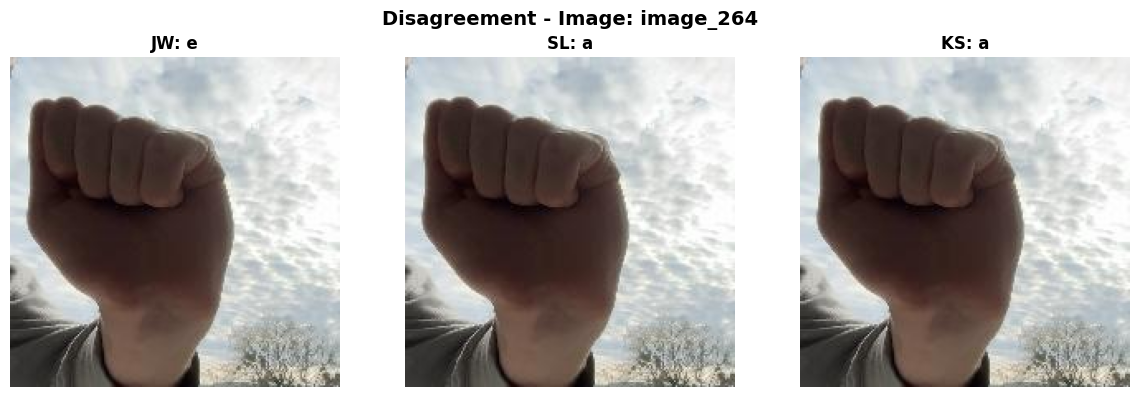

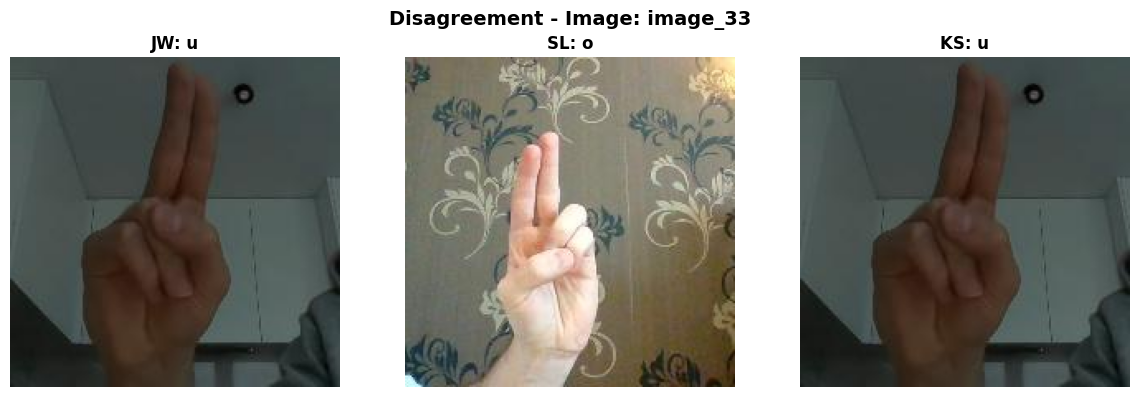

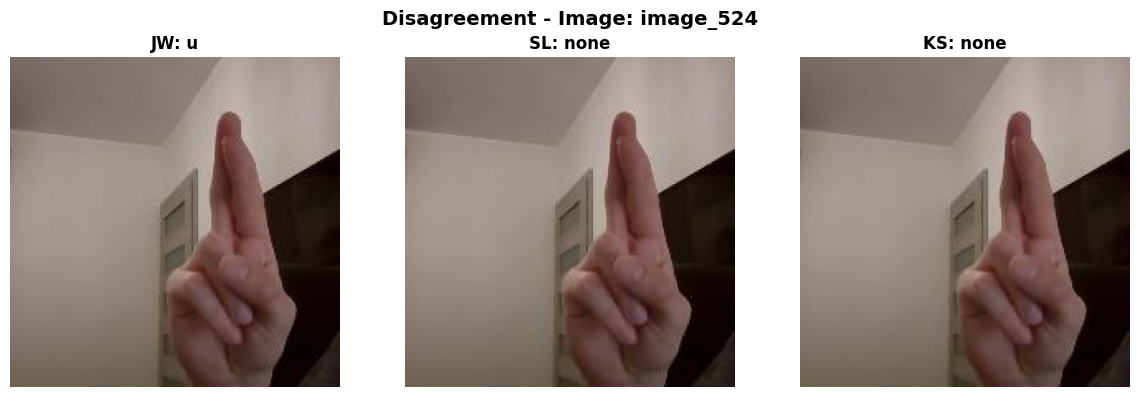

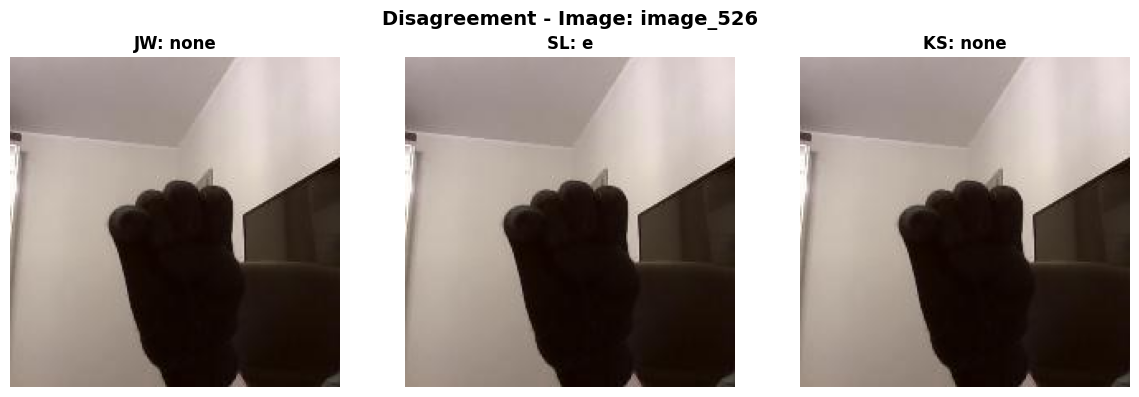

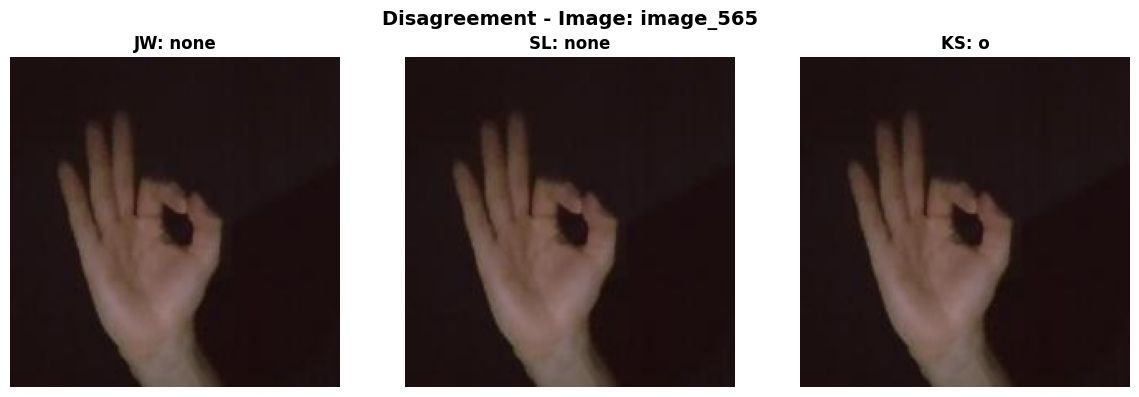

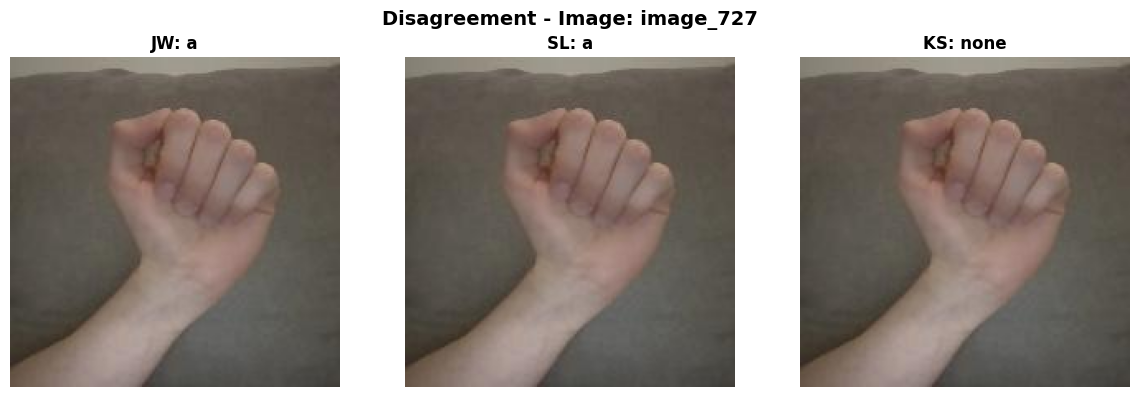

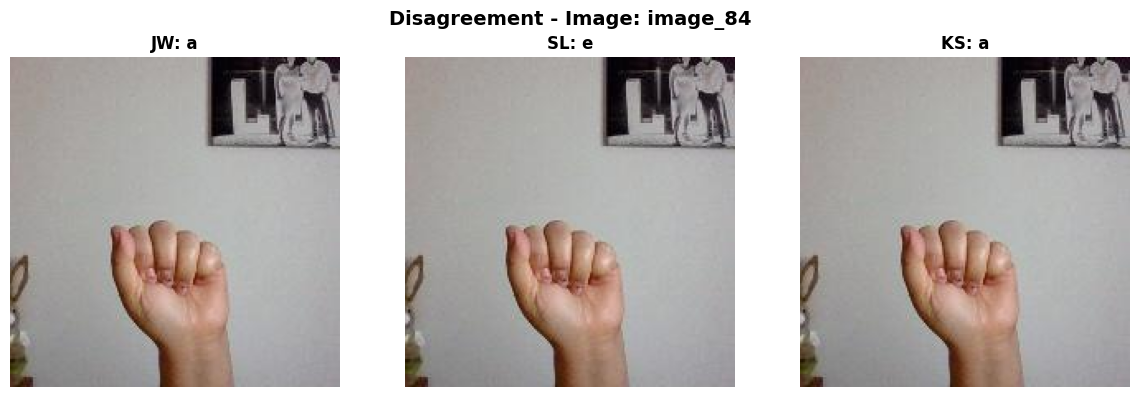

In [13]:
annotators = ["JW", "SL", "KS"]
paths = [path1, path2, path3]

for idx, row in disagreements.iterrows():
    img_name = row["Image Name"]
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Disagreement - Image: {img_name}", fontsize=14, fontweight='bold')
    
    for i, (annotator, path) in enumerate(zip(annotators, paths)):
        label = row[annotator]
        
        # Find the image file in the class directory
        class_dir = os.path.join(path, label)
        img_file = None
        
        if os.path.isdir(class_dir):
            for file in os.listdir(class_dir):
                if file.startswith(img_name):
                    img_file = os.path.join(class_dir, file)
                    break
        
        # Load and display the image
        if img_file and os.path.exists(img_file):
            img = Image.open(img_file)
            axes[i].imshow(img)
        else:
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center', 
                        transform=axes[i].transAxes, fontsize=12, color='red')
        
        axes[i].set_title(f"{annotator}: {label}", fontsize=12, fontweight='bold')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [23]:
def calculate_fleiss_kappa(df, annotator_columns):
    ratings_df = df[annotator_columns]
    
    initial_len = len(ratings_df)
    ratings_df = ratings_df.dropna()
    dropped = initial_len - len(ratings_df)
    
    ratings_array = ratings_df.values

    agg_matrix, categories = aggregate_raters(ratings_array)
    
    kappa_score = fleiss_kappa(agg_matrix, method='fleiss')
    
    return kappa_score

def calculate_krippendorff_alpha(df, annotator_columns):
    ratings_df = df[annotator_columns].copy()
    
    unique_classes = pd.unique(ratings_df.values.ravel('K'))
    unique_classes = [cat for cat in unique_classes if pd.notna(cat)]
    
    cls_to_num = {cat: float(i) for i, cat in enumerate(unique_classes)}
    
    numeric_ratings_df = ratings_df.replace(cls_to_num).astype(float)
    
    reliability_matrix = numeric_ratings_df.values.T
    
    alpha = krippendorff.alpha(reliability_data=reliability_matrix,
                               level_of_measurement='nominal')
    
    return alpha

In [25]:
print(calculate_fleiss_kappa(results_df, annotators))
print(calculate_krippendorff_alpha(results_df, annotators))

0.9587152957280888
0.958788108257669


In [ ]:
src_dirs = ["ZPD_Dataset_shared/train", "ZPD_annotated_by_everyone_merged/train"]
dst_folder = "ZPD_Final"

for unique_class in unique_classes:
	dst_class_path = os.path.join(dst_folder, unique_class)
	os.makedirs(dst_class_path, exist_ok=True)

	for src_dir in src_dirs:
		src_class_dir = os.path.join(src_dir, unique_class)
		for img_filename in os.listdir(src_class_dir):
			img_path = os.path.join(src_class_dir, img_filename)
			
			shutil.copy(img_path, dst_class_path)